Original shape: (5000, 36)
   subject_id  Count_subj  study_id  cart_id  Healthy_Status eeg_time   \
0    19557662          27  40000017  6848296               0   8:44 AM   
1    18477137          93  40000029  6848296               0   9:54 AM   
2    16598616           3  40000035  6376932               1   9:07 AM   
3    16368287           7  40000079  6214760               1   5:14 PM   
4    18370366           2  40000084  6632385               0   1:52 PM   

    eeg_date            report_0                           report_1  \
0  27.06.2015       Sinus rhythm  Possible right atrial abnormality   
1  27.06.2015       Sinus rhythm  Possible right atrial abnormality   
2  28.06.2015  Sinus tachycardia                                NaN   
3  15.07.2015       Sinus rhythm                                NaN   
4  27.09.2015       Sinus rhythm                                NaN   

                     report_2  ...                    filtering rr_interval  \
0                     

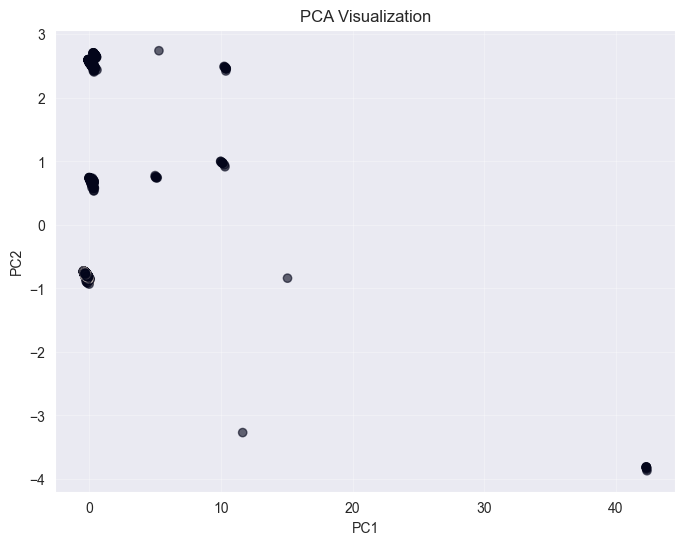


Explained variance ratio: [0.47150386 0.20765227]
Total explained variance: 0.6791561225533138


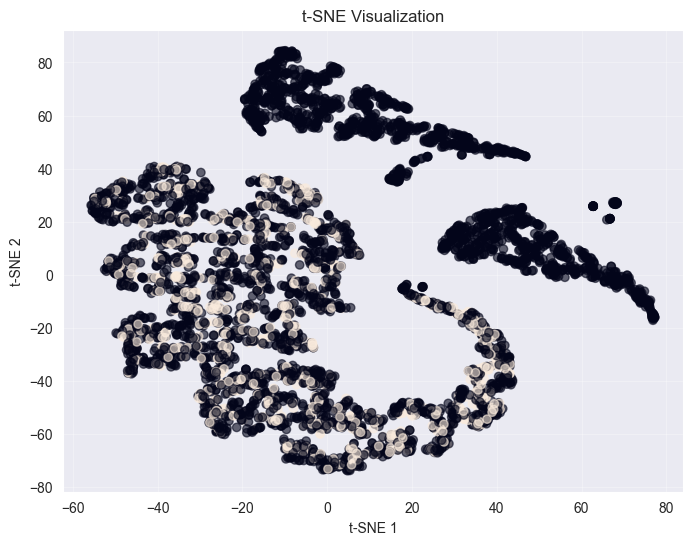


Model comparison:
                 Model  Accuracy  F1-score
0    Gradient Boosting     0.856  0.636364
1        Random Forest     0.859  0.627968
2          Extra Trees     0.857  0.590258
3                  KNN     0.783  0.398892
4  Logistic Regression     0.806  0.000000
5                  SVM     0.808  0.000000

Best model: Gradient Boosting


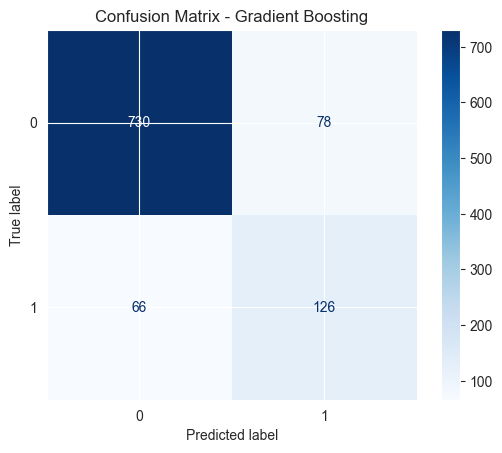


Final Accuracy: 0.856
Final F1-score: 0.6364

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       808
           1       0.62      0.66      0.64       192

    accuracy                           0.86      1000
   macro avg       0.77      0.78      0.77      1000
weighted avg       0.86      0.86      0.86      1000


===== Conclusion =====
1. The ECG dataset was processed for binary classification.
2. PCA and t-SNE were applied for dimensionality reduction and visualization.
3. Several classification models were compared automatically.
4. The best model was: Gradient Boosting.
5. Final F1-score: 0.6364.


In [2]:
# ================================
# ECG Binary Classification Project
# PCA + t-SNE + Automatic model comparison
# ================================

import os
# 解决 joblib 在 Windows 上无法检测物理核心数的警告
# 直接指定使用逻辑核心数（或手动设置一个数字，例如 "4"）
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    classification_report
)

# ================================
# 1. Load data
# ================================
url = "https://raw.githubusercontent.com/AI-is-out-there/data2lab/refs/heads/main/%D0%BC%D0%BE%D0%B4%D1%83%D0%BB%D1%8C%203%20-%20%D0%B4%D0%B0%D1%82%D0%B0%D1%81%D0%B5%D1%82%20-%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.csv"

df = pd.read_csv(url)
df = df.head(5000)

print("Original shape:", df.shape)
print(df.head())

# ================================
# 2. Select required columns
# ================================
columns = [
    'Count_subj',
    'rr_interval',
    'p_end',
    'qrs_onset',
    'qrs_end',
    'p_axis',
    'qrs_axis',
    't_axis',
    'Healthy_Status'
]

df = df[columns].copy()

print("\nSelected columns shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())

# ================================
# 3. Remove rows with missing target
# ================================
df = df.dropna(subset=['Healthy_Status']).copy()

# ================================
# 4. Split into features and target
# ================================
X = df.drop(columns=['Healthy_Status']).copy()
y = df['Healthy_Status'].copy()

# Encode target if needed
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nTarget classes:", list(label_encoder.classes_))
print("\nClass distribution:")
print(pd.Series(y).value_counts())

# ================================
# 5. Train-test split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ================================
# 6. Preprocessing for visualization
# ================================
viz_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_viz = viz_pipeline.fit_transform(X)

# ================================
# 7. PCA
# ================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_viz)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, alpha=0.6)
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# ================================
# 8. t-SNE
# ================================
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000
)
X_tsne = tsne.fit_transform(X_viz)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_encoded, alpha=0.6)
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, alpha=0.3)
plt.show()

# ================================
# 9. Candidate models
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier()
}

# ================================
# 10. Compare models automatically
# ================================
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='binary')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1-score': f1
    })

results_df = pd.DataFrame(results).sort_values(by='F1-score', ascending=False).reset_index(drop=True)

print("\nModel comparison:")
print(results_df)

# ================================
# 11. Best model
# ================================
best_model_name = results_df.loc[0, 'Model']
best_model = models[best_model_name]

print("\nBest model:", best_model_name)

best_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', best_model)
])

best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)

# ================================
# 12. Confusion matrix
# ================================
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# ================================
# 13. Final metrics
# ================================
final_acc = accuracy_score(y_test, y_pred_best)
final_f1 = f1_score(y_test, y_pred_best, average='binary')

print("\nFinal Accuracy:", round(final_acc, 4))
print("Final F1-score:", round(final_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=[str(c) for c in label_encoder.classes_]
))

# ================================
# 14. Final conclusion
# ================================
print("\n===== Conclusion =====")
print("1. The ECG dataset was processed for binary classification.")
print("2. PCA and t-SNE were applied for dimensionality reduction and visualization.")
print("3. Several classification models were compared automatically.")
print(f"4. The best model was: {best_model_name}.")
print(f"5. Final F1-score: {round(final_f1, 4)}.")